# 02 — Adjust the weights

The method's parameters are defined in `config/default.yaml`. This notebook changes the weights and reports how the ranking changes.

The whole method is data, not code. The taxonomy, the per-family weights, the two context deductions, and the 0-10 display scale all live in `config/default.yaml`. This notebook loads the 2022 World Cup once, scores it with the shipped weights, then re-scores it with an edited copy of the config to show how the ranking responds. Nothing about the pipeline changes between the two runs except the numbers passed in `config=`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath("../src"))
os.environ.setdefault("EXCITEMENT_INDEX_CACHE", os.path.abspath("../.opendata_cache"))
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.width", 140)

In [2]:
from pathlib import Path
from excitement_index import opendata, build_feature_matrix

CACHE = Path("wc2022_features.parquet")
matches = opendata.load_matches("FIFA World Cup", "2022")
if CACHE.exists():
    features = pd.read_parquet(CACHE)
else:
    features = build_feature_matrix(matches, opendata.load_events,
                                    elo=opendata.load_elo(), jeopardy=False)
    features.to_parquet(CACHE)
print(features.shape)

(64, 64)


## Baseline vs a re-weighted variant

This variant triples the resolution (goals) weight and reduces the stakes weight to 30% of its value. Weights must sum to 1, so they are renormalized after editing.

In [3]:
from excitement_index import score_matches, load_config

base = score_matches(features)
cfg = load_config()
w = dict(cfg["weights"])
w["resolution"] *= 3.0          # goals, goals, goals
w["stakes"] *= 0.3
total = sum(w.values())
w = {k: v / total for k, v in w.items()}
goalsy = score_matches(features, config={"weights": w})

cmp = pd.DataFrame({
    "match": base["home"] + " v " + base["away"],
    "base_rank": range(1, len(base) + 1),
}).set_index(base.index)
cmp["goalsy_rank"] = pd.Series(range(1, len(goalsy) + 1), index=goalsy.index)
cmp["moved"] = cmp["base_rank"] - cmp["goalsy_rank"]
cmp.reindex(cmp["moved"].abs().sort_values(ascending=False).index).head(10)

,match,base_rank,goalsy_rank,moved
match_id,,,,
3857291,Spain v Costa Rica,50,23,27
3857271,England v Iran,53,29,24
3869486,Morocco v Portugal,16,39,-23
3857279,France v Australia,44,24,20
3869151,Argentina v Australia,33,50,-17
3857298,Portugal v Ghana,34,17,17
3869118,England v Senegal,38,54,-16
3869552,France v Morocco,30,45,-15
3857278,Iran v United States,27,41,-14


The table above lists the matches whose rank moved the most between the two weightings. A positive `moved` means the match ranked higher under the goal-heavy weights. The score is a weighted average, so tripling the resolution (goals) weight and cutting the stakes weight lifts high-scoring matches and lowers tight, low-event games. Because the change is confined to the config, the same effect is reproducible by editing the file directly.

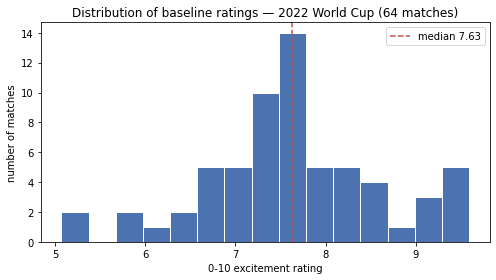

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(base["rating"], bins=15, color="#4C72B0", edgecolor="white")
med = base["rating"].median()
ax.axvline(med, color="#C44E52", ls="--", lw=1.5, label=f"median {med:.2f}")
ax.set_xlabel("0-10 excitement rating")
ax.set_ylabel("number of matches")
ax.set_title("Distribution of baseline ratings — 2022 World Cup (64 matches)")
ax.legend()
fig.tight_layout()
plt.show()

## Turn a tax off

One dict override — here, no dead-rubber tax at all.

In [5]:
no_tax = score_matches(features, config={"taxes": {"dead_rubber_k": 0.0}})
print("largest rating change from removing the dead-rubber tax:",
      float((no_tax["rating"] - base.loc[no_tax.index, "rating"]).abs().max()))

largest rating change from removing the dead-rubber tax: 0.0


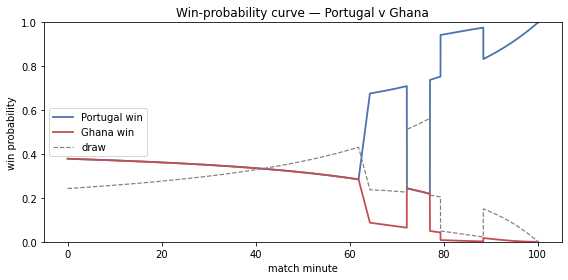

In [6]:
import matplotlib.pyplot as plt
from excitement_index import wp_curve
import excitement_index as ei

mid = 3857298  # Portugal v Ghana, a 3-2 group-stage match with lead swings
events = opendata.load_events(mid)
teams = set(events["team"].dropna().unique())
meta = features.loc[mid]
home = ei.resolve_team_name(meta["home"], teams)
away = ei.resolve_team_name(meta["away"], teams)
curve = wp_curve(events, home=home, away=away)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve["_t"], curve["p_home"], color="#4C72B0", lw=1.8, label=f"{home} win")
ax.plot(curve["_t"], curve["p_away"], color="#C44E52", lw=1.8, label=f"{away} win")
ax.plot(curve["_t"], curve["p_draw"], color="#808080", lw=1.2, ls="--", label="draw")
ax.set_xlabel("match minute")
ax.set_ylabel("win probability")
ax.set_ylim(0, 1)
ax.set_title(f"Win-probability curve — {home} v {away}")
ax.legend(loc="center left")
fig.tight_layout()
plt.show()